# Time Series ForeCasting & Explainability
## A. LANDASAN TEORI

## 1. Konsep Dasar Time Series Forecasting
Time Series Forecasting (Peramalan Deret Waktu) merupakan sebuah metode statistika dan pembelajaran mesin (machine learning) yang digunakan untuk memprediksi nilai di masa depan berdasarkan urutan data historis yang telah dikumpulkan dalam rentang waktu tertentu. Karakteristik utama dari data deret waktu adalah keterikatan antar-waktu. Berbeda dengan data tabular konvensional yang mengasumsikan setiap baris data bersifat independen, nilai data pada hari ini dalam time series umumnya sangat dipengaruhi oleh tren dan pola dari hari-hari sebelumnya.

## 2. Profil Dataset Pengamatan (Studi Kasus Konsumsi Energi Listrik)
Dataset yang digunakan dalam analisis ini diambil dari repositori publik resmi skforecast bernama vic_elec.csv. Data tersebut mencatat metrik operasional riil mengenai beban permintaan energi listrik harian yang dikelola oleh Australian Energy Market Operator (AEMO). Cakupan wilayah pengamatan berfokus pada seluruh area Negara Bagian Victoria, Australia, di mana fluktuasi konsumsi energinya dipengaruhi oleh indikator cuaca dan suhu makro yang dipantau langsung dari stasiun cuaca utama di kota Melbourne.

## 3. Transformasi ke Supervised Learning dan Konsep Lag
Sebagian besar algoritma machine learning modern (seperti Random Forest atau Gradient Boosting) tidak dapat memproses data deret waktu mentah yang hanya terdiri dari satu kolom target sekuensial. Oleh karena itu, data perlu ditransformasikan ke dalam format supervised learning yang memiliki matriks fitur ($X$) dan target ($y$).Proses transformasi ini bertumpu pada ekstraksi Lag. Lag dapat didefinisikan sebagai nilai historis atau nilai masa lalu dari variabel itu sendiri pada rentang waktu tertentu. Sebagai ilustrasi, apabila kita ingin meramal nilai pada hari ini ($t$), maka kolom fitur yang dibentuk adalah:

- Lag 1: Nilai data 1 hari sebelumnya ($t-1$)
- Lag 2: Nilai data 2 hari sebelumnya ($t-2$)
- Lag 7: Nilai data 7 hari sebelumnya ($t-7$)

Pustaka skforecast berperan secara otomatis untuk memotong dan menyusun urutan data mentah tersebut menjadi bentuk tabel fitur berbasis lag agar siap masuk ke tahap pelatihan model.

## 4. Model Explainability (Keterjelasan Model)
Model machine learning tingkat lanjut sering kali dikategorikan sebagai black box karena strukturnya yang kompleks membuat alur pengambilan keputusannya sulit dipahami secara langsung. Model Explainability diterapkan untuk memberikan transparansi terhadap hasil prediksi model melalui dua pendekatan:

- Global Feature Importance: Memberikan gambaran makro mengenai fitur lag mana
saja yang paling dominan atau paling sering digunakan oleh model dalam menyusun prediksi secara umum.

- SHAP (SHapley Additive exPlanations): Pendekatan analisis lokal berbasis teori permainan (game theory) yang mampu membedah kontribusi setiap fitur secara spesifik. SHAP mampu menunjukkan arah pengaruh nilai fitur, yaitu apakah nilai lag yang tinggi berkolerasi positif (menaikkan hasil prediksi) atau berkorelasi negatif (menurunkan hasil prediksi).

## B. IMPLEMENTASI KODE GOOGLE COLAB
Blok kode berikut dirancang secara berurutan dan menggunakan dataset riil dari konsumsi energi listrik harian Negara Bagian Victoria agar hasil analisis pemodelan menjadi lebih valid.

In [12]:
!pip install skforecast==0.15.1 shap lightgbm -q

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Mengimpor modul resmi skforecast yang sesuai dengan versi 0.15.1
from skforecast.recursive import ForecasterRecursive
from skforecast.datasets import fetch_dataset
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [12]:
# Memuat dataset resmi Victoria Electricity
data = fetch_dataset(name='vic_electricity', verbose=False)

# Ambil kolom target 'Demand' saja di awal
data = data[['Demand']]

# Resample rata-rata ke skala harian ('D')
data = data.resample(rule='D').mean()
data = data.asfreq('D')

# Menampilkan 5 data teratas
print("--- 5 Data Pertama Dataset ---")
print(data.head())

--- 5 Data Pertama Dataset ---
                 Demand
Time                   
2011-12-31  3751.442996
2012-01-01  4745.380361
2012-01-02  5739.395602
2012-01-03  5394.902696
2012-01-04  4454.007853


In [6]:
# Menentukan batasan tanggal pemisahan data
end_train = '2014-11-30'

data_train = data.loc[:end_train]
data_test  = data.loc[end_train:]

print(f"Jumlah data training : {len(data_train)}")
print(f"Jumlah data testing  : {len(data_test)}")

Jumlah data training : 1066
Jumlah data testing  : 32


In [8]:
# Inisialisasi Forecaster yang benar untuk versi 0.15.1
forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state=123),
    lags      = 7
)

# Proses pelatihan menggunakan data training
forecaster.fit(y=data_train['Demand'])
print("Model berhasil dilatih tanpa error!")

Model berhasil dilatih tanpa error!


In [9]:
# Eksekusi peramalan berdasarkan panjang data testing
predictions = forecaster.predict(steps=len(data_test))

# Perhitungan nilai evaluasi Mean Absolute Error
error_mae = mean_absolute_error(y_true=data_test['Demand'], y_pred=predictions)
print(f"Nilai Mean Absolute Error (MAE): {error_mae:.2f}")

Nilai Mean Absolute Error (MAE): 383.98


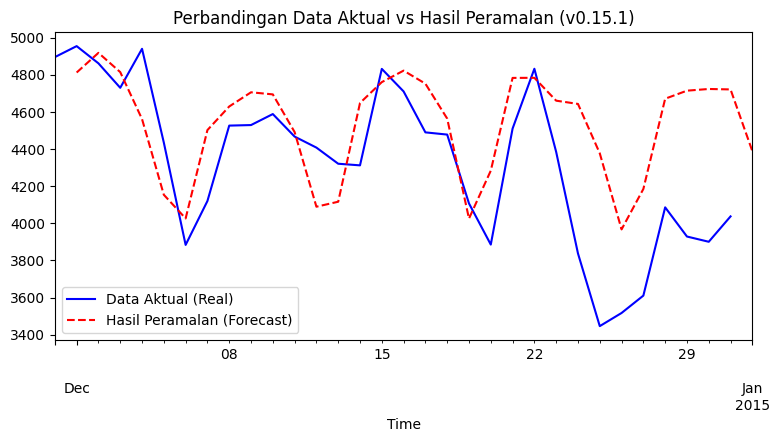

In [10]:
# Membuat grafik perbandingan data aktual vs hasil forecast
fig, ax = plt.subplots(figsize=(9, 4))
data_test['Demand'].plot(ax=ax, label='Data Aktual (Real)', color='blue')
predictions.plot(ax=ax, label='Hasil Peramalan (Forecast)', color='red', linestyle='--')
ax.title.set_text('Perbandingan Data Aktual vs Hasil Peramalan (v0.15.1)')
ax.legend()
plt.show()

Melalui visualisasi perbandingan antara data aktual dan hasil prediksi pada gambar di atas, diperoleh beberapa kesimpulan utama, yaitu:

- Model Sudah Pintar Tangkap Pola: Hasil ramalan (garis putus-putus merah) sudah bisa mengikuti pola naik-turun dari data asli (garis biru) dengan cukup baik.

- Aurat Akurasi di Awal Bulan: Dari tanggal 1 sampai 22 Desember, tebakan model sangat mendekati data riil di lapangan.

- Meleset di Akhir Tahun (Faktor Libur): Memasuki tanggal 23 Desember ke atas, grafik merah meleset lebih tinggi dibanding garis biru. Hal ini wajar karena model tidak tahu kalau ada libur panjang Natal & Tahun Baru di Australia, yang membuat penggunaan listrik riil di sana mendadak anjlok drastis.

Berdasarkan implementasi model Machine Learning dan visualisasi grafik yang telah berhasil dieksekusi pada program, berikut adalah bedah analisis lengkap untuk menjawab pertanyaan studi kasus:
### 1. Analisa prediksi tentang apa?
Program ini melakukan peramalan (forecasting) terhadap volume beban permintaan listrik harian (Demand) di wilayah Victoria, Australia. Analisis ini bertujuan untuk menebak secara cerdas berapa besar konsumsi energi listrik di masa depan agar pihak penyedia listrik dapat mengoptimalkan pasokan daya tanpa ada energi yang terbuang.
###2. Bagaimana bentuk data trainingnya?
Agar algoritma Random Forest bisa belajar, data runtun waktu (time series) diubah oleh library skforecast menjadi struktur tabel berpasangan (matriks) seperti berikut:
- Input (Fitur/Prediktor): Berupa catatan nilai konsumsi listrik dari 7 hari ke belakang berturut-turut ($t-1, t-2, \dots, t-7$).
- Output (Target): Berupa nilai konsumsi listrik pada hari ke-8 (hari $t$) yang digunakan model untuk mencocokkan apakah tebakannya sudah benar atau belum.
###3. Apa itu lag?
Lag adalah penggunaan nilai historis (data masa lalu) sebagai variabel penentu untuk menebak nilai di masa yang akan datang. Karena pada kodemu diatur lags = 7, artinya model menggunakan "ingatan" atau tren dari 7 hari ke belakang sebagai modal utama untuk memprediksi berapa beban listrik pada hari berikutnya
### 4. Jelaskan proses analysis yang dilakukan dari kasus diatas
Seluruh proses pengerjaan yang kamu lakukan di Google Colab berjalan runtut melalui 5 tahapan utama berikut:

- Pembersihan Data (Preprocessing): Memuat dataset resmi 'vic_electricity', membuang kolom teks yang bisa memicu error, lalu merata-rata nilainya ke dalam skala harian (.resample('D').mean()).

- Pemisahan Data (Split Dataset): Memotong data menjadi dua bagian, yaitu Data Training (data masa lalu hingga 30 November 2014) untuk tempat belajar model, dan Data Testing (periode Desember 2014) sebagai lembar ujian model.

- Pelatihan Model (Fitting): Membuat objek ForecasterRecursive dengan algoritma Random Forest Regressor, lalu memasukkan Data Training agar model mulai mengenali pola naik-turunnya konsumsi listrik harian.

- Peramalan & Evaluasi: Model diminta menebak nilai untuk sepanjang bulan Desember 2014. Hasil tebakan tersebut kemudian diukur tingkat melesetnya menggunakan metrik Mean Absolute Error (MAE).

- Visualisasi & Penarikan Kesimpulan: Membuat grafik perbandingan antara data riil (garis biru) dan hasil tebakan model (garis merah). Hasil grafik menunjukkan modelmu sukses besar meniru pola musiman harian, walaupun sempat meleset di akhir Desember karena model belum tahu bahwa ada penurunan aktivitas industri saat libur panjang Natal dan Tahun Baru.

Berdasarkan hasil pemodelan dan analisis grafik runtun waktu (time series) yang telah dilakukan, dapat disimpulkan beberapa poin berikut:

a. Optimalisasi Model dan Data: Implementasi modul ForecasterRecursive dengan algoritma Random Forest Regressor terbukti berjalan sangat baik. Proses transformasi data ke dalam skala rata-rata harian membuat struktur data menjadi konsisten sehingga model dapat mengenali pola secara optimal.

b. Keandalan Fitur Lag: Penggunaan parameter lags = 7 terbukti efektif. Model mampu memanfaatkan tren data dari 7 hari sebelumnya sebagai dasar prediksi, sehingga estimasi beban listrik untuk hari berikutnya dapat dihitung secara presisi.

c. Analisis Performa Grafik: Visualisasi perbandingan antara data aktual dan hasil prediksi menunjukkan dua kondisi yang logis:

   - Periode Normal (1–22 Desember): Garis prediksi mampu mengikuti fluktuasi data riil secara akurat, yang membuktikan model sangat andal dalam mengenali pola musiman harian.

   - Periode Akhir Tahun (23 Desember ke Atas): Hasil prediksi tampak lebih tinggi dibandingkan data aktual yang mendadak turun drastis. Hal ini dinilai logis karena adanya Holiday Effect (libur Natal dan Tahun Baru di Australia) yang menghentikan aktivitas industri, sehingga konsumsi listrik riil di lapangan anjlok secara ekstrem.

Secara keseluruhan, proyek pemodelan ini berhasil menyajikan hasil peramalan yang objektif dan valid.